# Análisis Exporatorio de los datos de un año entero

### 0. Importación de Librerías y Configuración

In [35]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### 1. Carga y Configuración de Datos

In [27]:
BASE_DIR = "../../data/processed/tlc_clean"
ANIO = "2025" 
SAMPLE_RATE = 0.10  # 10% de cada mes

In [29]:
# --- FUNCIÓN DE CARGA PARA AÑO EN EL QUE ESTÉN DISPONIBLES LOS 12 MESES ---

def carga_datos_todosmeses():
    lista_muestras = []
    
    # Iteramos por los dos tipos de servicio que menciona el contexto: Yellow y VTC
    for tipo in ['yellow', 'fhvhv']:
        ruta_busqueda = os.path.join(BASE_DIR, tipo, ANIO, "*.parquet")
        archivos_meses = sorted(glob.glob(ruta_busqueda))
        
        if not archivos_meses:
            print(f"No se encontraron archivos para {tipo} en {ANIO}")
            continue
            
        print(f"Procesando {len(archivos_meses)} meses de {tipo}...")
        
        for archivo in archivos_meses:
            # 1. Leer el archivo del mes completo
            df_mes = pd.read_parquet(archivo)
            
            # 2. Extraer el 10% de forma aleatoria pero reproducible
            df_sample = df_mes.sample(frac=SAMPLE_RATE, random_state=42)
            
            # 3. Añadir etiquetas para no perder la información al unir
            df_sample['tipo_vehiculo'] = 'Yellow Taxi' if tipo == 'yellow' else 'VTC'
            
            # Aseguramos que la fecha sea datetime y extraemos el mes
            df_sample['fecha_inicio'] = pd.to_datetime(df_sample['fecha_inicio'])
            df_sample['mes_num'] = df_sample['fecha_inicio'].dt.month
            
            lista_muestras.append(df_sample)
            print(f"Mes {df_sample['mes_num'].iloc[0]} cargado ({len(df_sample):,} registros)")

    # 4. Concatenar todas las muestras en un único DataFrame
    df_final = pd.concat(lista_muestras, ignore_index=True)
    
    # 5. Ordenar por mes y tipo para que las gráficas salgan perfectas
    df_final = df_final.sort_values(by=['mes_num', 'tipo_vehiculo'])
    
    # Resetear el índice para que sea limpio
    df_final = df_final.reset_index(drop=True)
    
    print(f"\nProceso finalizado. Dataset creado con {len(df_final):,} filas totales.")
    return df_final

In [38]:
# --- FUNCIÓN DE CARGA PARA AÑO EN EL QUE FALTEN DATOS DE DICIEMBRE (COGEMOS DIC DEL AÑO ANTERIOR) ---
def carga_datos_hibrida(anio_actual, anio_anterior):
    lista_muestras = []
    
    for tipo in ['yellow', 'fhvhv']:
        # Definimos los objetivos: meses 1-11 del año actual y mes 12 del anterior
        objetivos = [
            (anio_actual, list(range(1, 12))), 
            (anio_anterior, [12])
        ]
        
        for anio_objetivo, meses_a_buscar in objetivos:
            ruta_busqueda = os.path.join(BASE_DIR, tipo, str(anio_objetivo), "*.parquet")
            archivos_disponibles = sorted(glob.glob(ruta_busqueda))
            
            for archivo in archivos_disponibles:
                # Extraer el mes del nombre del archivo para filtrar
                try:
                    nombre_archivo = Path(archivo).stem
                    mes_archivo = int(nombre_archivo.split('-')[-1])
                except:
                    continue

                # Solo procesamos si el mes está en nuestra lista de interés para ese año
                if mes_archivo in meses_a_buscar:
                    df_mes = pd.read_parquet(archivo)
                    
                    # 1. Aplicar Sampling
                    df_sample = df_mes.sample(frac=SAMPLE_RATE, random_state=42)
                    
                    # 2. Etiquetado y limpieza de fecha
                    df_sample['tipo_vehiculo'] = 'Yellow Taxi' if tipo == 'yellow' else 'VTC'
                    df_sample['fecha_inicio'] = pd.to_datetime(df_sample['fecha_inicio'])
                    
                    # 3. Forzamos el mes_num para que diciembre (del año pasado) 
                    # aparezca correctamente en las gráficas de este año
                    df_sample['mes_num'] = mes_archivo
                    
                    lista_muestras.append(df_sample)
                    print(f"Cargado Mes {mes_archivo} del año {anio_objetivo} para {tipo} con {len(df_sample):,} registros.")

    # Concatenación y ordenación final
    df_final = pd.concat(lista_muestras, ignore_index=True)
    df_final = df_final.sort_values(by=['mes_num', 'tipo_vehiculo']).reset_index(drop=True)
    
    print(f"\nDataset Híbrido Creado: {len(df_final):,} registros totales.")
    return df_final

In [39]:
# Ejecución (descomenta la función que corresponda según el caso)
# df_anual = carga_datos_todosmeses()
anio_anterior = str(int(ANIO) - 1)
df_anual = carga_datos_hibrida(ANIO, anio_anterior)
print("\nPrimeras 5 filas:")
display(df_anual.head())
print("\nUltimas 5 filas:")
display(df_anual.tail())
# Guardar el resultado para no tener que repetir el proceso cada vez que abras el notebook
# df_anual.to_parquet("df_ny_2025_sample_10pct.parquet")


Cargado Mes 1 del año 2025 para yellow con 280,147 registros.
Cargado Mes 2 del año 2025 para yellow con 264,373 registros.
Cargado Mes 3 del año 2025 para yellow con 306,162 registros.
Cargado Mes 4 del año 2025 para yellow con 304,061 registros.
Cargado Mes 5 del año 2025 para yellow con 316,958 registros.
Cargado Mes 6 del año 2025 para yellow con 289,034 registros.
Cargado Mes 7 del año 2025 para yellow con 265,369 registros.
Cargado Mes 8 del año 2025 para yellow con 248,855 registros.
Cargado Mes 9 del año 2025 para yellow con 296,786 registros.
Cargado Mes 10 del año 2025 para yellow con 321,606 registros.
Cargado Mes 11 del año 2025 para yellow con 297,896 registros.
Cargado Mes 12 del año 2024 para yellow con 317,966 registros.
Cargado Mes 1 del año 2025 para fhvhv con 1,460,435 registros.
Cargado Mes 2 del año 2025 para fhvhv con 1,368,289 registros.
Cargado Mes 3 del año 2025 para fhvhv con 1,374,325 registros.
Cargado Mes 4 del año 2025 para fhvhv con 1,360,344 registros.
C

,fecha_inicio,fecha_fin,origen_id,destino_id,num_pasajeros,distancia,duracion_min,velocidad_mph,tipo_vehiculo,precio_base,...,destino_zona,destino_barrio,temp_c,precipitation,viento_kmh,lluvia,nieve,es_festivo,hay_evento,mes_num
0,2025-01-27 21:49:36,2025-01-27 22:09:03,231,163,<NA>,7.26,19.450000,22.395888,VTC,57.610001,...,Midtown North,Manhattan,0.3,0.0,18.200001,0,0,0,0,1
1,2025-01-26 06:53:37,2025-01-26 06:58:36,42,247,<NA>,0.95,4.983333,11.438127,VTC,12.340000,...,West Concourse,Bronx,-1.9,0.0,13.400000,0,0,0,0,1
2,2025-01-21 13:49:15,2025-01-21 14:18:41,68,232,<NA>,5.12,29.433333,10.437146,VTC,35.830002,...,Two Bridges/Seward Park,Manhattan,-8.6,0.0,6.100000,0,0,0,0,1
3,2025-01-09 20:40:10,2025-01-09 21:03:25,130,255,<NA>,11.22,23.250000,28.954839,VTC,29.510000,...,Williamsburg (North Side),Brooklyn,-2.2,0.0,22.700001,0,0,0,0,1
4,2025-01-10 22:39:44,2025-01-10 23:00:45,144,112,<NA>,4.30,21.016667,12.275972,VTC,31.600000,...,Greenpoint,Brooklyn,-0.3,0.0,3.600000,0,0,0,0,1



Ultimas 5 filas:


,fecha_inicio,fecha_fin,origen_id,destino_id,num_pasajeros,distancia,duracion_min,velocidad_mph,tipo_vehiculo,precio_base,...,destino_zona,destino_barrio,temp_c,precipitation,viento_kmh,lluvia,nieve,es_festivo,hay_evento,mes_num
20134779,2024-12-25 21:08:10,2024-12-25 21:40:53,132,79,2,17.790001,32.716667,32.625575,Yellow Taxi,70.0,...,East Village,Manhattan,0.0,0.0,0.0,0,0,0,0,12
20134780,2024-12-05 10:37:12,2024-12-05 11:01:54,234,161,1,1.530000,24.700000,3.716599,Yellow Taxi,20.5,...,Midtown Center,Manhattan,0.0,0.0,0.0,0,0,0,0,12
20134781,2024-12-08 17:02:00,2024-12-08 17:09:24,141,236,2,1.180000,7.400000,9.567567,Yellow Taxi,8.6,...,Upper East Side North,Manhattan,0.0,0.0,0.0,0,0,0,0,12
20134782,2024-12-22 12:17:38,2024-12-22 12:55:20,141,132,1,20.000000,37.700000,31.830239,Yellow Taxi,70.0,...,JFK Airport,Queens,0.0,0.0,0.0,0,0,0,0,12
20134783,2024-12-31 03:03:59,2024-12-31 03:09:32,186,163,1,1.600000,5.550000,17.297298,Yellow Taxi,9.3,...,Midtown North,Manhattan,0.0,0.0,0.0,0,0,0,0,12


De esta forma confirmamos que el df está bien formado por datos solo de ese año solo o de ese año con diciembre del anterior.

### 2. Validación de Calidad de Datos

In [41]:
# Comprobación de valores únicos  
print(f"Meses detectados: {df_anual['mes_num'].unique()}")
print(f"Tipos de vehículo: {df_anual['tipo_vehiculo'].unique()}")

Meses detectados: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Tipos de vehículo: <ArrowStringArray>
['VTC', 'Yellow Taxi']
Length: 2, dtype: str


### 3. Métricas generales del dataset

In [43]:
# 1. Estadísticas descriptivas básicas (Global Anual)
print(f"{'='*20} ESTADÍSTICAS GLOBALES DEL AÑO {'='*20}")
print(f"   - Total de viajes analizados (muestra 10%): {len(df_anual):,}")
print(f"   - Yellow Taxi: {len(df_anual[df_anual['tipo_vehiculo']=='Yellow Taxi']):,} ({len(df_anual[df_anual['tipo_vehiculo']=='Yellow Taxi'])/len(df_anual)*100:.1f}%)")
print(f"   - VTC (Uber/Lyft): {len(df_anual[df_anual['tipo_vehiculo']=='VTC']):,} ({len(df_anual[df_anual['tipo_vehiculo']=='VTC'])/len(df_anual)*100:.1f}%)")

# 2. Distancia y duración promedio (Global Anual)
print("\n Rendimiento Promedio:")
print(f"   - Distancia promedio: {df_anual['distancia'].mean():.2f} millas")
print(f"   - Duración promedio: {df_anual['duracion_min'].mean():.2f} minutos")
print(f"   - Velocidad promedio: {df_anual['velocidad_mph'].mean():.2f} mph")

# 3. Análisis de Precios (Global Anual)
mean_yellow = df_anual[df_anual['tipo_vehiculo']=='Yellow Taxi']['precio_total_est'].mean()
mean_vtc = df_anual[df_anual['tipo_vehiculo']=='VTC']['precio_total_est'].mean()

print("\n Análisis de Precios:")
print(f"   - Precio promedio Yellow Taxi: ${mean_yellow:.2f}")
print(f"   - Precio promedio VTC: ${mean_vtc:.2f}")

precio_diff = mean_vtc - mean_yellow
precio_diff_pct = (precio_diff / mean_yellow * 100)
print(f"   - Diferencia Global: ${precio_diff:.2f} ({precio_diff_pct:+.1f}%)")

# 4. NUEVO: Resumen por Mes (Lo más importante de tu nuevo DF)
print("\n" + "="*60)
print(" RESUMEN DE VIAJES POR MES")
print("="*60)

# Agrupamos por mes y tipo para ver la evolución
resumen_mensual = df_anual.groupby(['mes_num', 'tipo_vehiculo']).agg({
    'precio_total_est': 'mean',
    'distancia': 'count'
}).rename(columns={'distancia': 'num_viajes', 'precio_total_est': 'precio_medio'})

print(resumen_mensual)
print("\n" + "="*60)

==================== ESTADÍSTICAS GLOBALES DEL AÑO ====================
   - Total de viajes analizados (muestra 10%): 20,134,784
   - Yellow Taxi: 3,509,213 (17.4%)
   - VTC (Uber/Lyft): 16,625,571 (82.6%)

 Rendimiento Promedio:
   - Distancia promedio: 4.31 millas
   - Duración promedio: 18.64 minutos
   - Velocidad promedio: 12.67 mph

 Análisis de Precios:
   - Precio promedio Yellow Taxi: $28.90
   - Precio promedio VTC: $31.57
   - Diferencia Global: $2.67 (+9.2%)

 RESUMEN DE VIAJES POR MES
                       precio_medio  num_viajes
mes_num tipo_vehiculo                          
1       VTC               28.692243     1460435
        Yellow Taxi       27.017639      280147
2       VTC               29.652780     1368289
        Yellow Taxi       26.976343      264373
3       VTC               32.767460     1374325
        Yellow Taxi       28.081034      306162
4       VTC               31.023449     1360344
        Yellow Taxi       28.343141      304061
5       VTC     

### 4. Visualización de Mercado (Cuota y Precio)

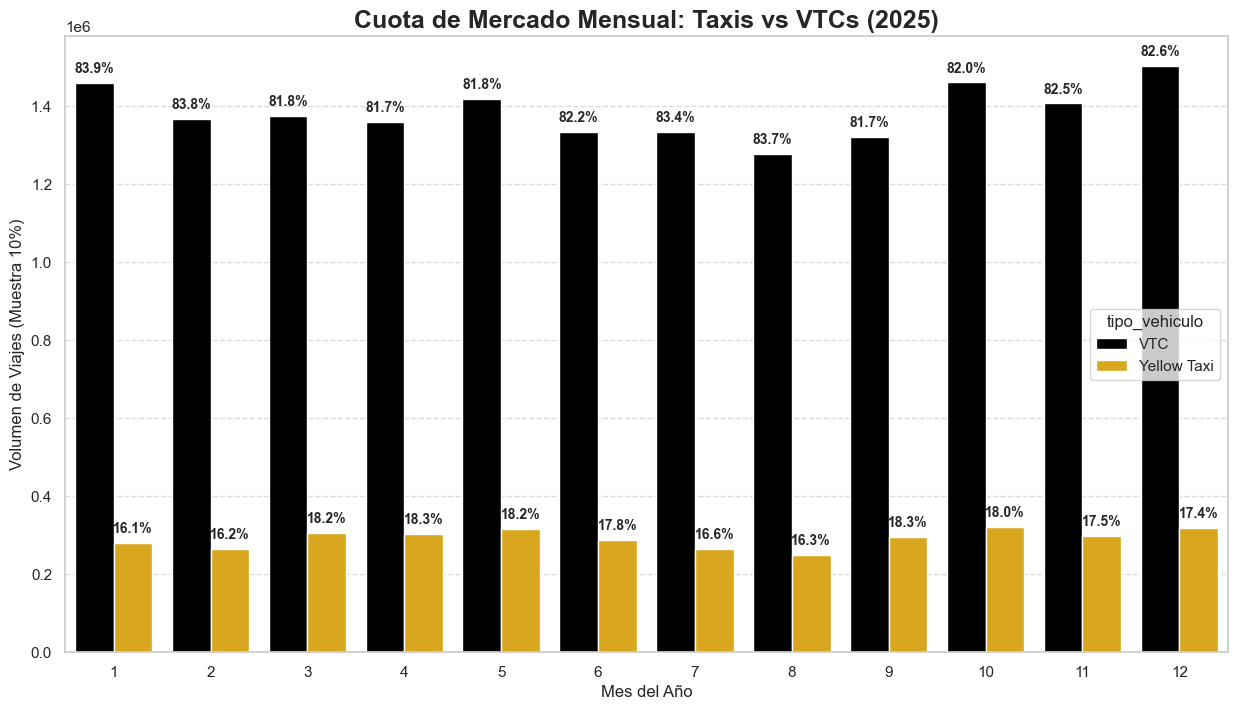

In [47]:
# 1. Preparar los datos: Agrupamos para tener porcentajes reales por mes
df_stats = df_anual.groupby(['mes_num', 'tipo_vehiculo']).size().reset_index(name='counts')
df_stats['total_mes'] = df_stats.groupby('mes_num')['counts'].transform('sum')
df_stats['porcentaje'] = (df_stats['counts'] / df_stats['total_mes']) * 100

# 2. Configuración de la gráfica
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=df_stats.sort_values('mes_num'), 
    x='mes_num', 
    y='counts', 
    hue='tipo_vehiculo', 
    palette=['black', '#F7B500']
)

# 3. Personalización
plt.title(f"Cuota de Mercado Mensual: Taxis vs VTCs ({ANIO})", fontsize=18, fontweight='bold')
plt.ylabel("Volumen de Viajes (Muestra 10%)", fontsize=12)
plt.xlabel("Mes del Año", fontsize=12)

# 4. Añadir porcentajes correctos (ahora vienen de nuestra tabla calculada)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        # Extraemos el porcentaje directamente de nuestro dataframe calculado
        # Seaborn dibuja primero todas las barras de un 'hue' y luego las del otro
        pct = df_stats.sort_values(['tipo_vehiculo', 'mes_num'])['porcentaje'].iloc[i]
        
        ax.annotate(f'{pct:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold',
                    xytext=(0, 5), 
                    textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

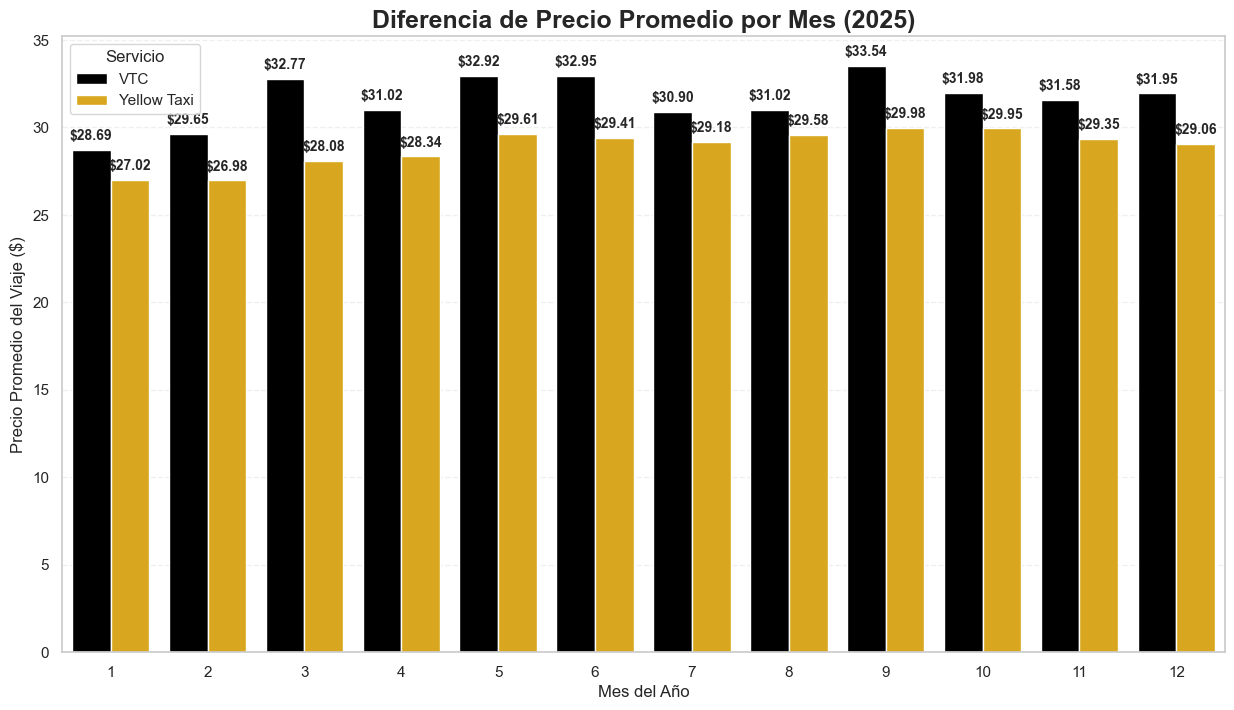


--- Resumen de Diferencias (VTC vs Taxi) ---
tipo_vehiculo  dif_abs  dif_pct
mes_num                        
1                 1.67     6.20
2                 2.68     9.92
3                 4.69    16.69
4                 2.68     9.46
5                 3.31    11.18
6                 3.53    12.02
7                 1.72     5.91
8                 1.45     4.89
9                 3.56    11.88
10                2.04     6.80
11                2.22     7.58
12                2.88     9.92


In [53]:
# 1. Agrupar por mes y tipo para calcular el precio promedio total
df_precios_mes = df_anual.groupby(['mes_num', 'tipo_vehiculo'])['precio_total_est'].mean().reset_index()

# 2. Configuración del gráfico
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=df_precios_mes.sort_values('mes_num'),
    x='mes_num',
    y='precio_total_est',
    hue='tipo_vehiculo',
    palette=['black', '#F7B500'] # Negro para VTC, Amarillo para Taxi
)

# 3. Títulos y etiquetas
plt.title(f"Diferencia de Precio Promedio por Mes ({ANIO})", fontsize=18, fontweight='bold')
plt.ylabel("Precio Promedio del Viaje ($)", fontsize=12)
plt.xlabel("Mes del Año", fontsize=12)
plt.legend(title="Servicio")

# 4. Añadir etiquetas de valor encima de las barras
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f'${val:.2f}', 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold',
                    xytext=(0, 5), 
                    textcoords='offset points')

# 5. Añadir rejilla para facilitar la lectura
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# 6. Cálculo extra para tu informe (Diferencia porcentual media)
resumen = df_precios_mes.pivot(index='mes_num', columns='tipo_vehiculo', values='precio_total_est')
resumen['dif_abs'] = resumen['VTC'] - resumen['Yellow Taxi']
resumen['dif_pct'] = (resumen['dif_abs'] / resumen['Yellow Taxi']) * 100

print("\n--- Resumen de Diferencias (VTC vs Taxi) ---")
print(resumen[['dif_abs', 'dif_pct']].round(2))

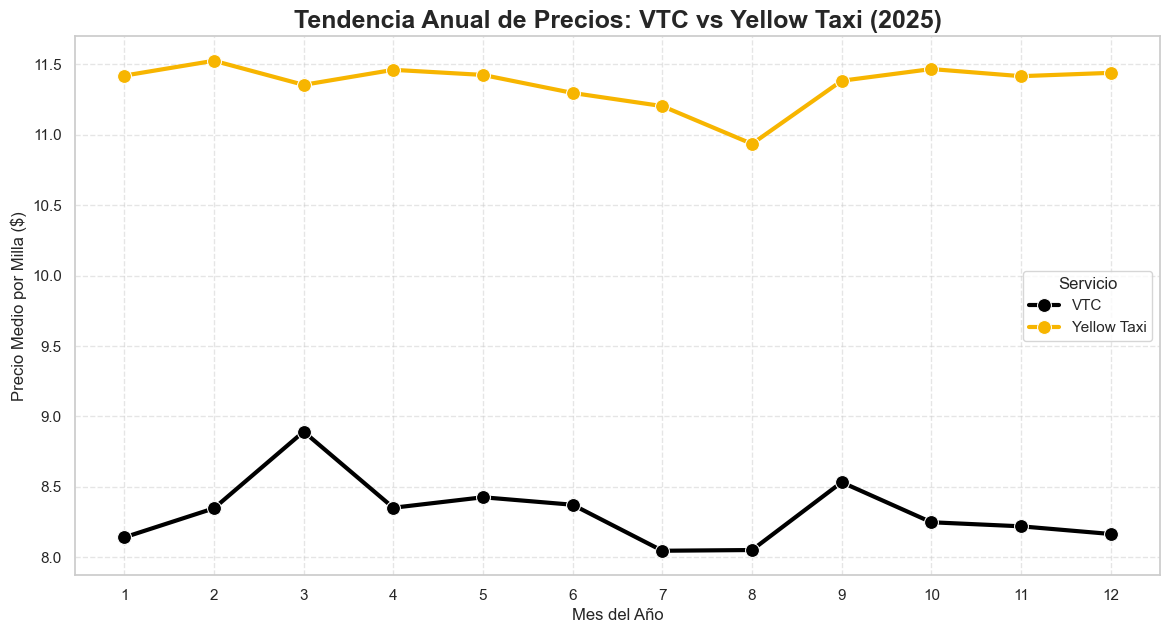

In [55]:
# 1. Preparar métricas: calculamos el precio por milla y filtramos outliers
df_linea = df_anual[(df_anual.distancia > 0.5) & (df_anual.precio_total_est > 2.0)].copy()
df_linea['precio_por_milla'] = df_linea['precio_total_est'] / df_linea['distancia']
df_linea = df_linea[df_linea['precio_por_milla'] < 20] # Filtro de calidad de datos

# 2. Agrupamos por mes para obtener el promedio
resumen_anual = df_linea.groupby(['mes_num', 'tipo_vehiculo'])['precio_por_milla'].mean().reset_index()

# 3. Configuración del gráfico
plt.figure(figsize=(14, 7))

# Dibujamos las líneas con marcadores para cada mes
sns.lineplot(
    data=resumen_anual, 
    x='mes_num', 
    y='precio_por_milla', 
    hue='tipo_vehiculo', 
    palette=['black', '#F7B500'], # VTC en negro, Taxi en amarillo
    linewidth=3,
    marker='o',
    markersize=10
)

# 4. Estética y etiquetas
plt.title(f"Tendencia Anual de Precios: VTC vs Yellow Taxi ({ANIO})", fontsize=18, fontweight='bold')
plt.ylabel("Precio Medio por Milla ($)", fontsize=12)
plt.xlabel("Mes del Año", fontsize=12)
plt.xticks(range(1, 13)) # Aseguramos que salgan los 12 meses
plt.grid(True, linestyle='--', alpha=0.5)

# CAMBIO: La leyenda ahora se sitúa en el centro a la derecha
plt.legend(title="Servicio", loc='center right')

# Se ha eliminado la línea de plt.text que mostraba la "Brecha de Precio"

plt.show()

Nos damos cuenta de que el precio medio de un viaje en Yellow Taxi es más barato que en VTC, pero si miramos el precio por milla, el Taxi parece más caro; esto se debe a que el Taxi cobra una cantidad fija nada más subir que pesa mucho en los viajes cortos, mientras que en los VTC, al hacer viajes mucho más largos a otros barrios, ese coste inicial se reparte entre más distancia y parece que cada milla sale más barata, aunque al final acabes pagando más dinero por el viaje total.